In [91]:
import pandas as pd

In [92]:
pd.read_csv(r"C:\Users\ACER\Downloads\Employee-Attrition - Employee-Attrition.csv")
df = pd.read_csv(r"C:\Users\ACER\Downloads\Employee-Attrition - Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [62]:
df.isnull().sum().sum()

np.int64(0)

In [63]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool

In [93]:
# DROPPING unwanted columns by domain knowledge

df_clean = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours','DailyRate','HourlyRate','EmployeeNumber','PercentSalaryHike','StockOptionLevel','JobInvolvement',
                  'TrainingTimesLastYear','YearsWithCurrManager'],axis=1,errors='ignore')
df_clean.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobLevel,...,MonthlyRate,NumCompaniesWorked,OverTime,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,2,...,19479,8,Yes,3,1,8,1,6,4,0
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,24907,1,No,4,4,10,3,10,7,1
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,1,...,2396,6,Yes,3,2,7,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,1,...,23159,1,Yes,3,3,8,3,8,7,3
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,1,...,16632,9,No,3,4,6,3,2,2,2


In [94]:
df_clean.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PerformanceRating', 'RelationshipSatisfaction', 'TotalWorkingYears',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion'],
      dtype='object')

In [95]:
# EDA

import seaborn as sns
import matplotlib.pyplot as plt

In [96]:
# defining TARGET column

df_clean['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

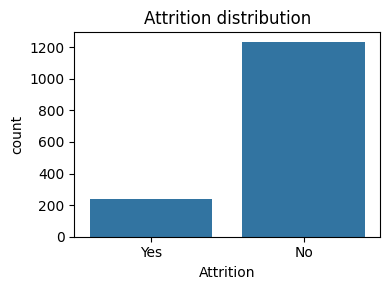

In [97]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x="Attrition")
plt.title("Attrition distribution")
plt.tight_layout()
plt.show()

In [98]:
#encoding categorical columns
df_clean['OverTime'] = df_clean['OverTime'].map({'Yes': 1, 'No': 0})
df_clean['MaritalStatus'] = df_clean['MaritalStatus'].map({
    'Single': 0,
    'Married': 1,
    'Divorced': 2
})
df_clean['Gender'] = df_clean['Gender'].map({'Female': 1, 'Male': 0})
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

In [99]:
#one hot encoding
df_clean = df_clean.join(pd.get_dummies(df_clean['BusinessTravel'])).drop('BusinessTravel',axis=1)
df_clean = df_clean.join(pd.get_dummies(df_clean['Department'],prefix='Department')).drop('Department',axis=1)
df_clean = df_clean.join(pd.get_dummies(df_clean['EducationField'],prefix='Education')).drop('EducationField',axis=1)
df_clean = df_clean.join(pd.get_dummies(df_clean['JobRole'],prefix='Role')).drop('JobRole',axis=1)

In [100]:
df_clean.head()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,JobLevel,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Education_Technical Degree,Role_Healthcare Representative,Role_Human Resources,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative
0,41,1,1,2,2,1,2,4,0,5993,...,False,False,False,False,False,False,False,False,True,False
1,49,0,8,1,3,0,2,2,1,5130,...,False,False,False,False,False,False,False,True,False,False
2,37,1,2,2,4,0,1,3,0,2090,...,False,False,False,True,False,False,False,False,False,False
3,33,0,3,4,4,1,1,3,1,2909,...,False,False,False,False,False,False,False,True,False,False
4,27,0,2,1,1,0,1,2,1,3468,...,False,False,False,True,False,False,False,False,False,False


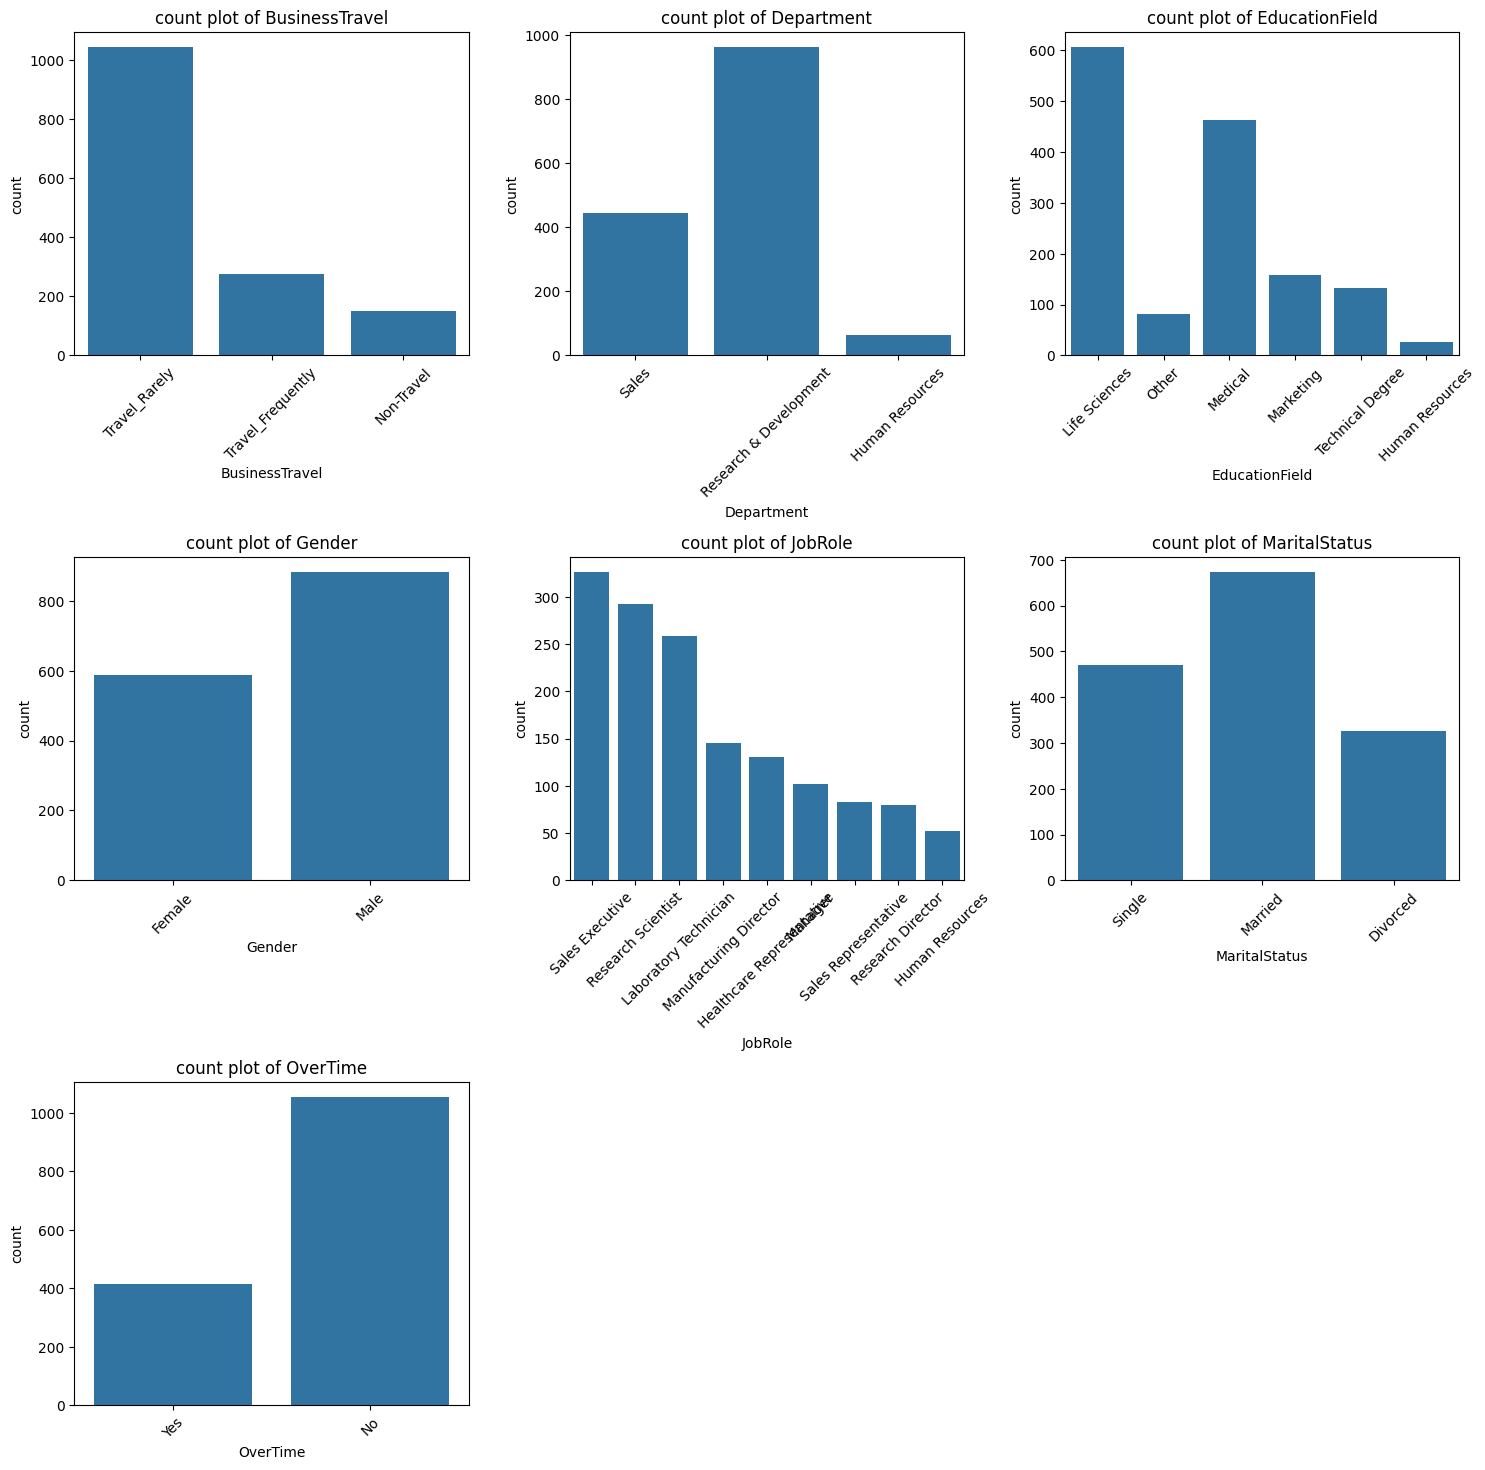

In [13]:
# Univariate analyse for categorical_cols:

cat_cols = ['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']
plt.figure(figsize=(15,30))
for i, col in enumerate(cat_cols,1):
    plt.subplot(6,3,i)
    sns.countplot(data=df_clean,x= col)
    plt.title(f"count plot of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

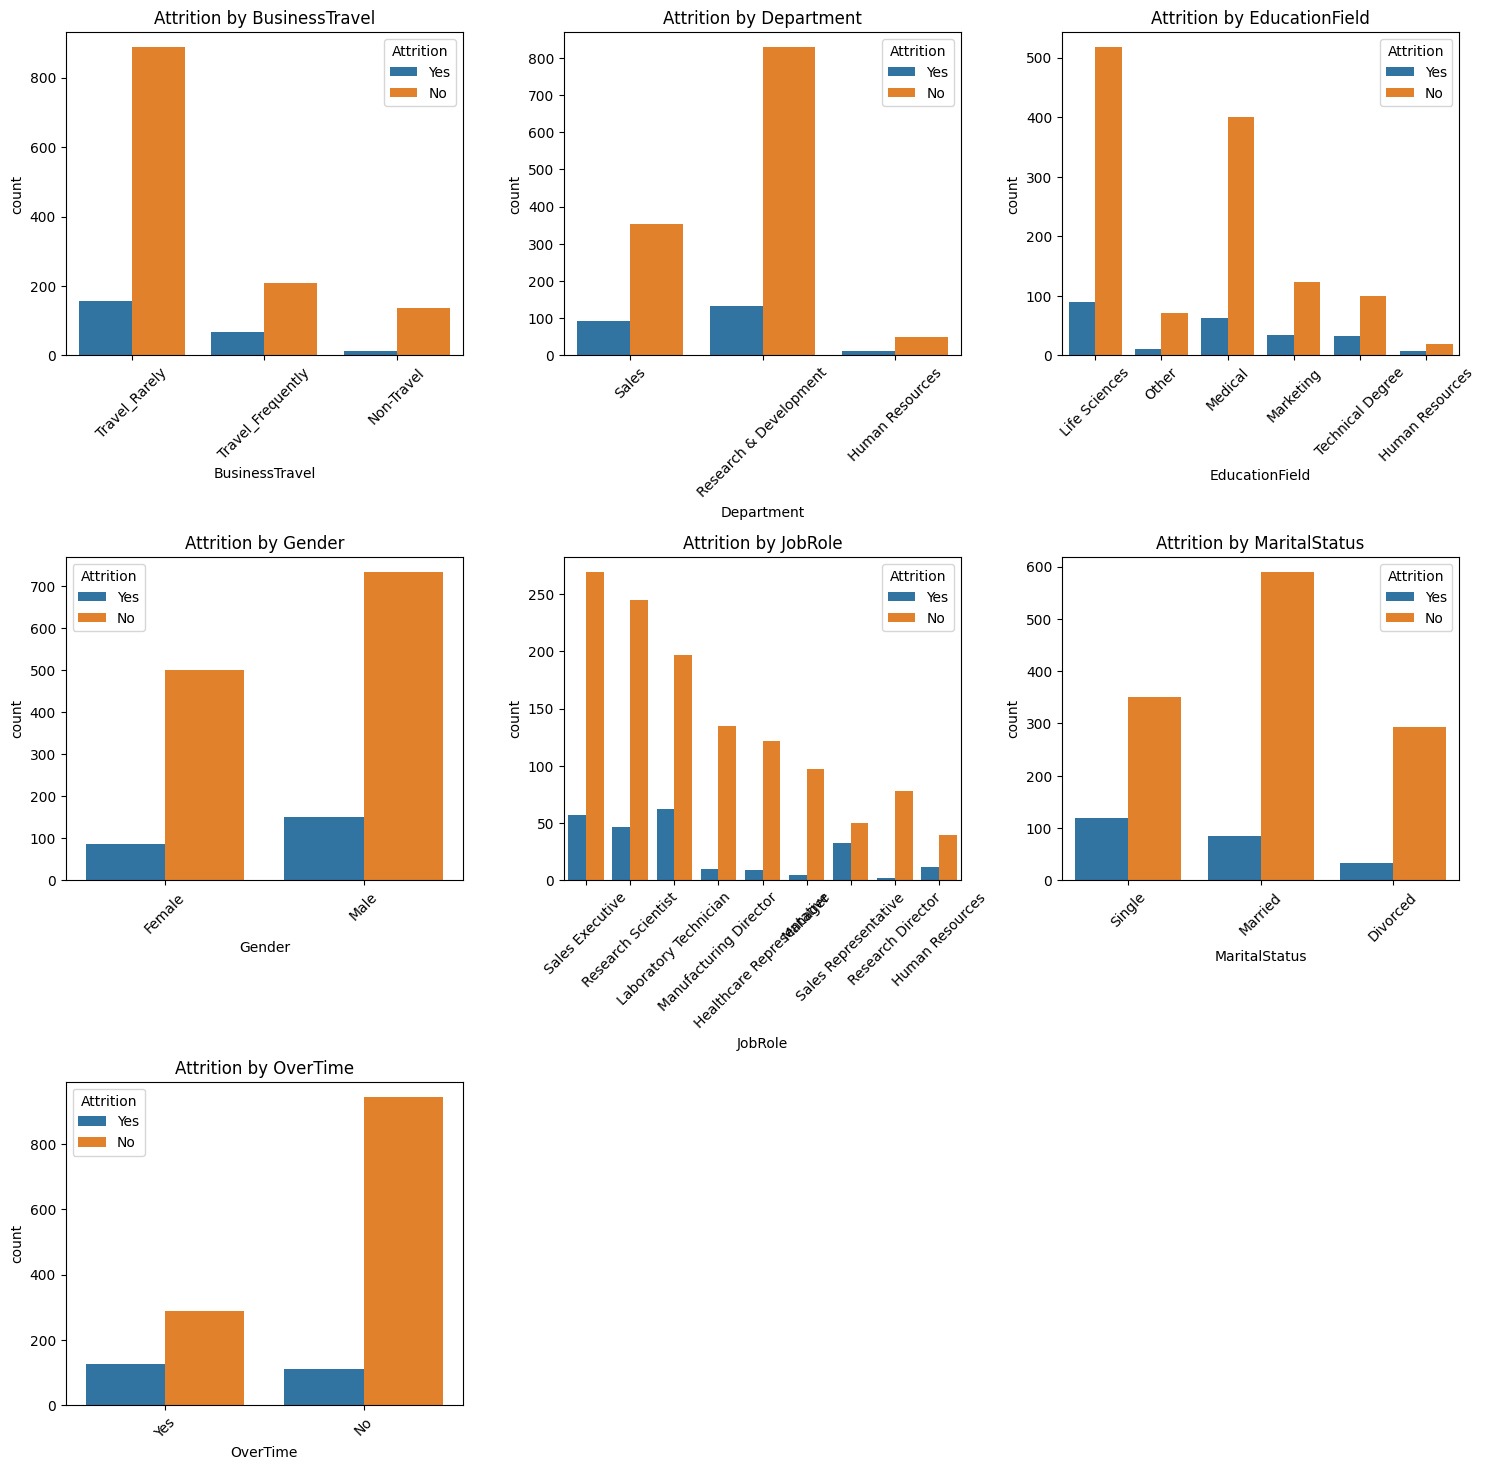

In [14]:
# Bivariate analyse for categorical_cols:

plt.figure(figsize=(15,30))
for i, col in enumerate(cat_cols,1):
    plt.subplot(6,3,i)
    sns.countplot(data=df_clean,x= col, hue="Attrition")
    plt.title(f"Attrition by {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


=====Numeric feature:Age =====
Mean: 36.92 Median: 36.0
Mean - Median Difference %: 2.5 %
Skewness: 0.41


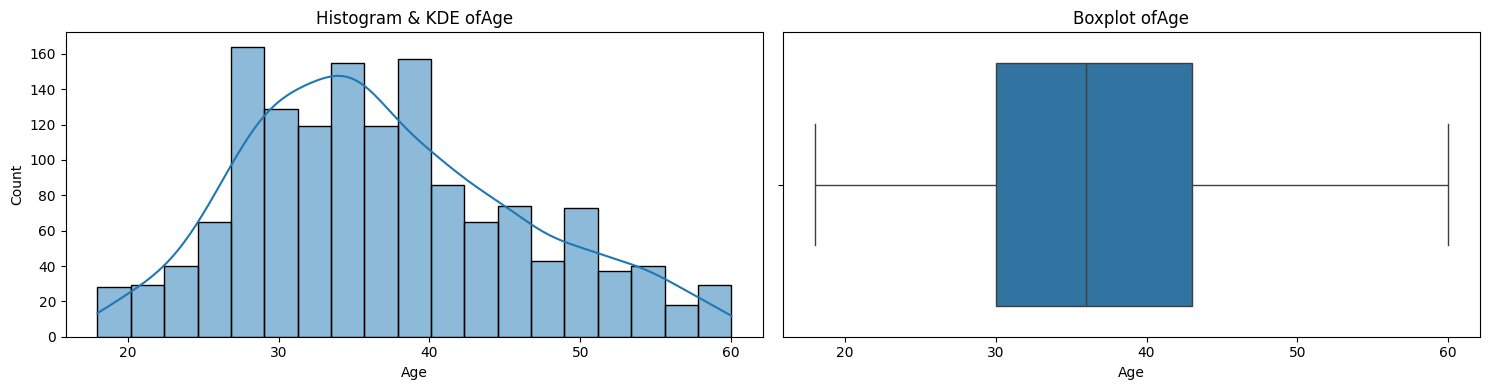


=====Numeric feature:DistanceFromHome =====
Mean: 9.19 Median: 7.0
Mean - Median Difference %: 23.85 %
Skewness: 0.96


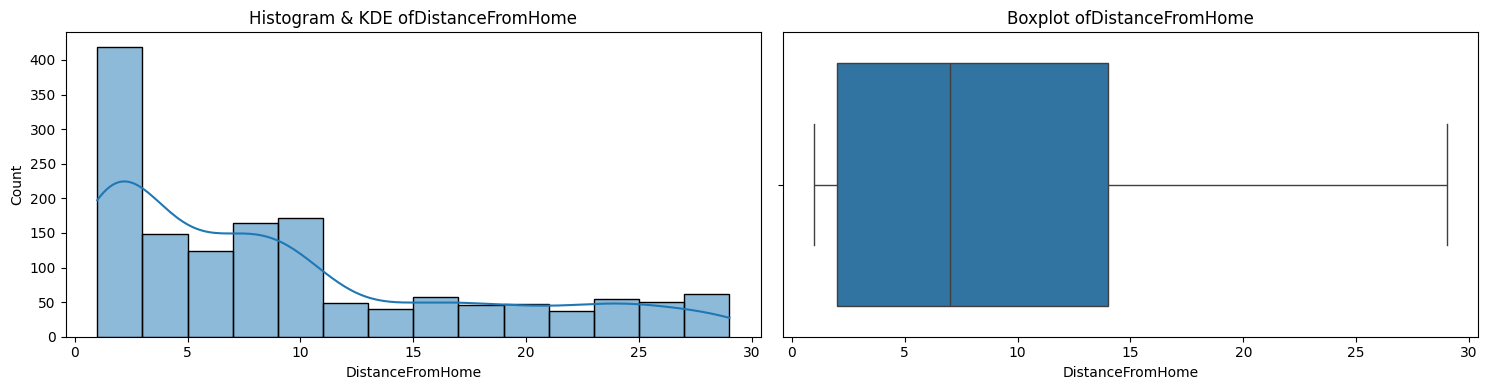


=====Numeric feature:EnvironmentSatisfaction =====
Mean: 2.72 Median: 3.0
Mean - Median Difference %: 10.22 %
Skewness: -0.32


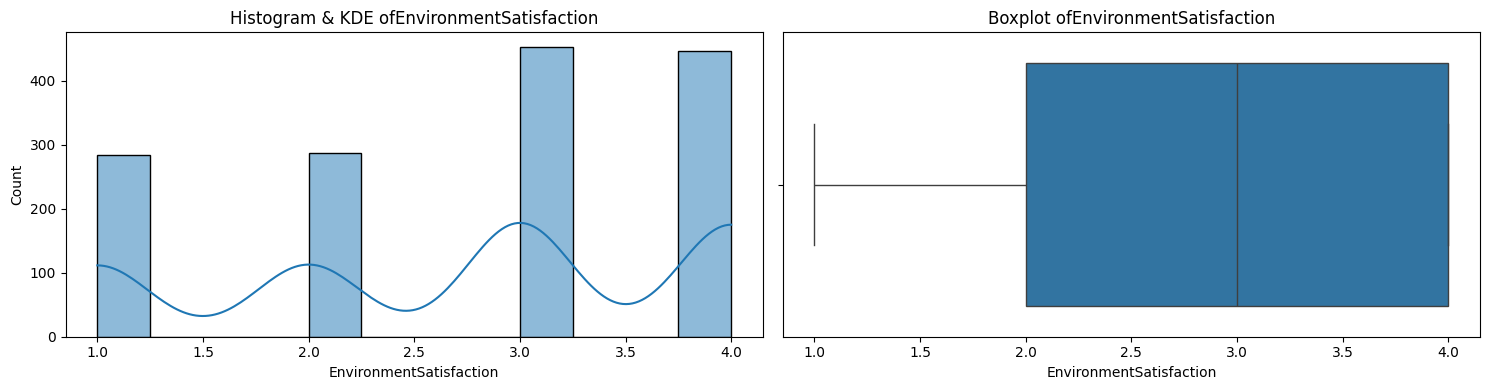


=====Numeric feature:JobInvolvement =====
Mean: 2.73 Median: 3.0
Mean - Median Difference %: 9.89 %
Skewness: -0.5


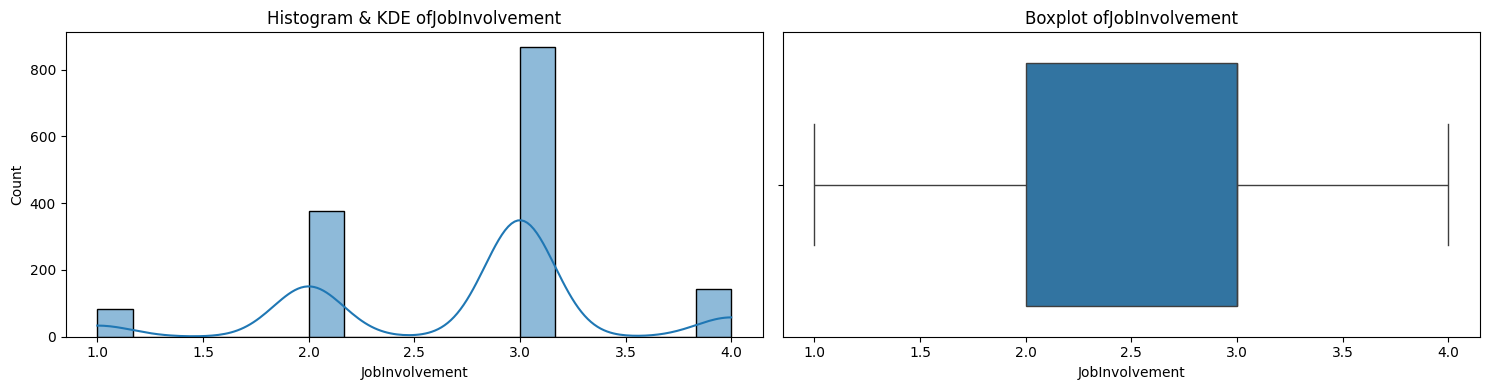


=====Numeric feature:JobLevel =====
Mean: 2.06 Median: 2.0
Mean - Median Difference %: 3.1 %
Skewness: 1.03


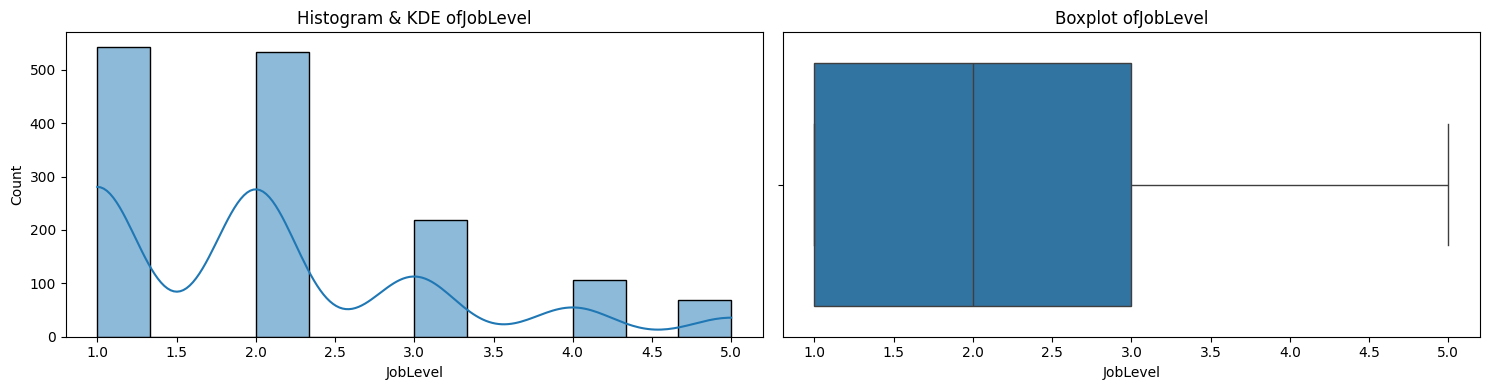


=====Numeric feature:JobSatisfaction =====
Mean: 2.73 Median: 3.0
Mean - Median Difference %: 9.95 %
Skewness: -0.33


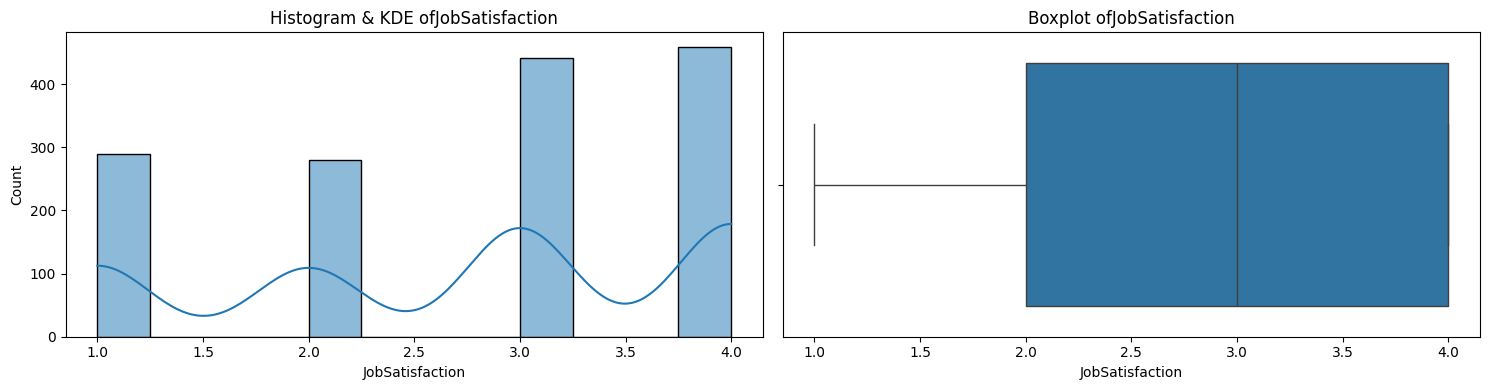


=====Numeric feature:MonthlyIncome =====
Mean: 6502.93 Median: 4919.0
Mean - Median Difference %: 24.36 %
Skewness: 1.37


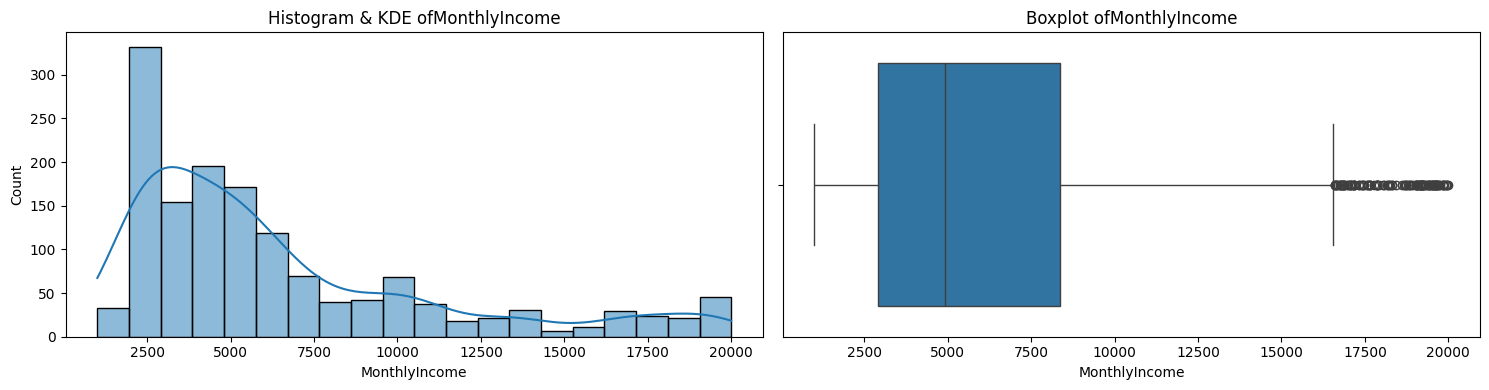


=====Numeric feature:PerformanceRating =====
Mean: 3.15 Median: 3.0
Mean - Median Difference %: 4.87 %
Skewness: 1.92


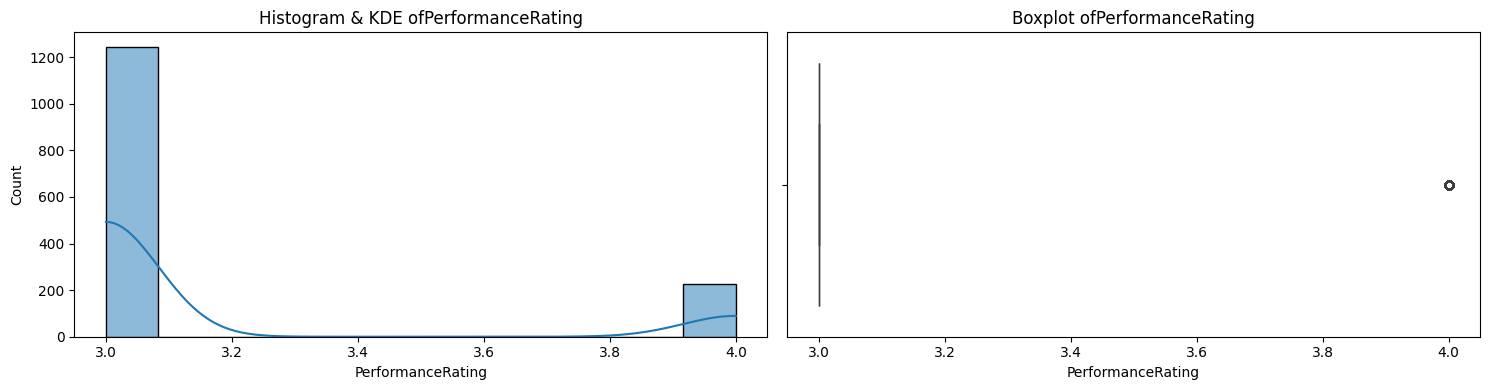


=====Numeric feature:WorkLifeBalance =====
Mean: 2.76 Median: 3.0
Mean - Median Difference %: 8.65 %
Skewness: -0.55


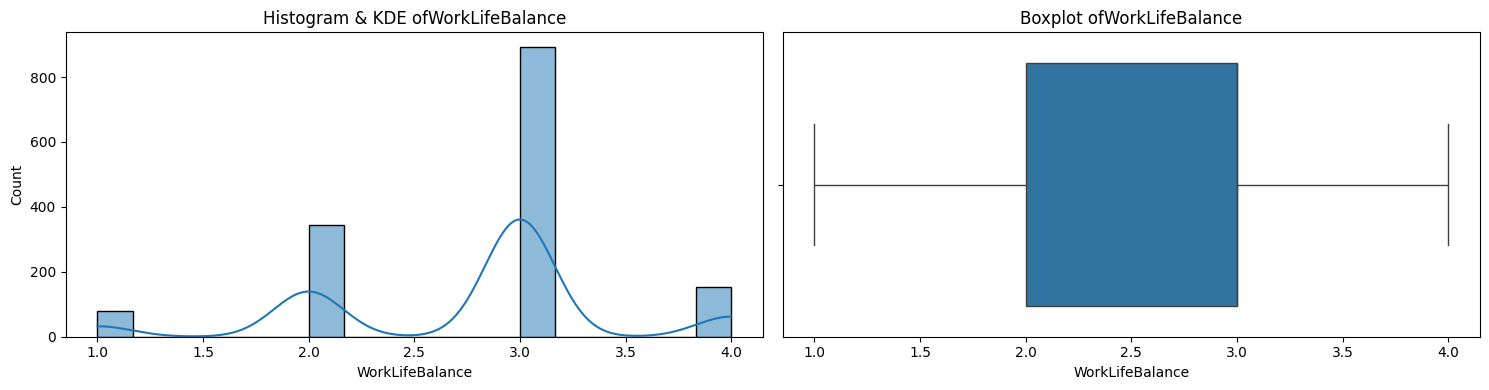


=====Numeric feature:TotalWorkingYears =====
Mean: 11.28 Median: 10.0
Mean - Median Difference %: 11.34 %
Skewness: 1.12


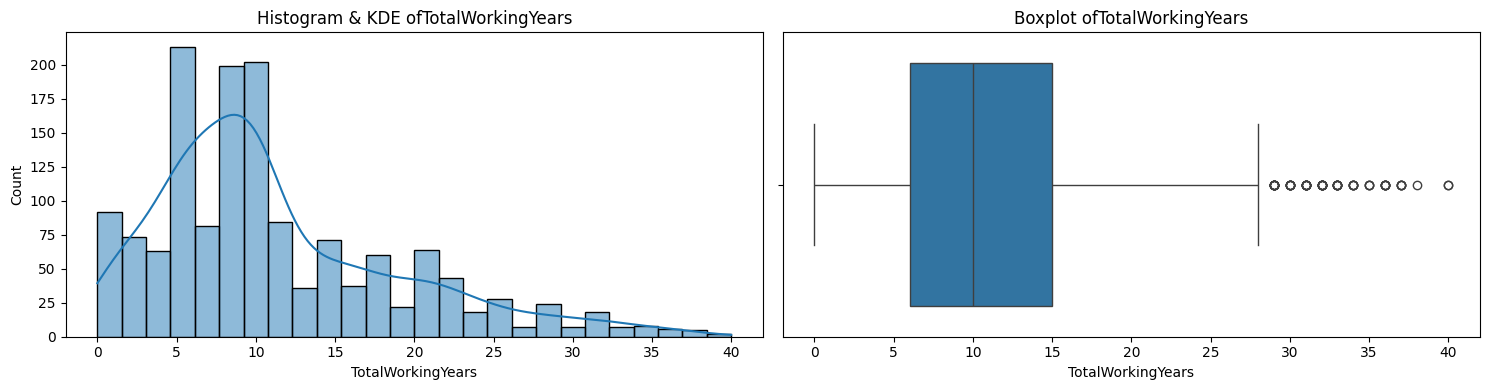


=====Numeric feature:YearsAtCompany =====
Mean: 7.01 Median: 5.0
Mean - Median Difference %: 28.65 %
Skewness: 1.76


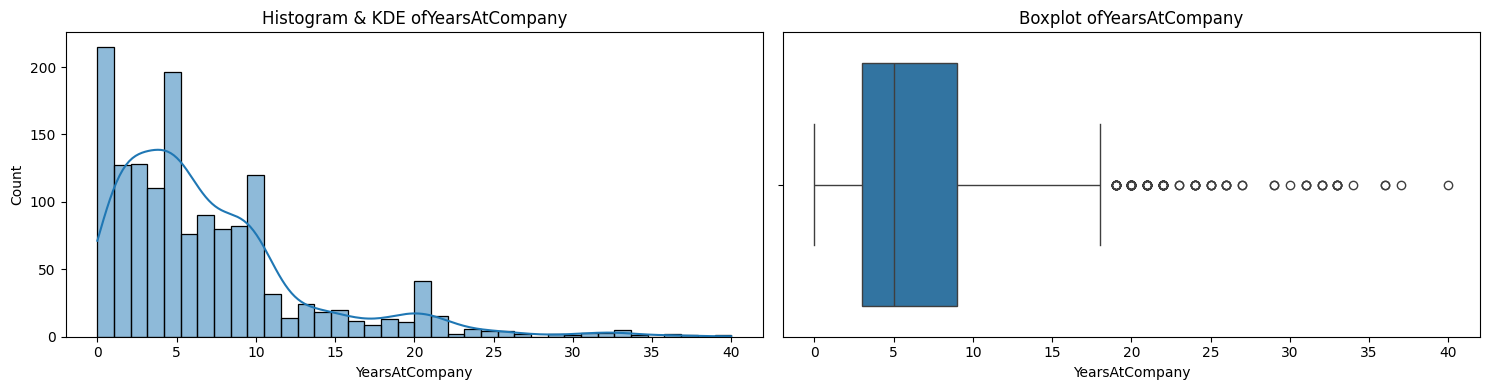


=====Numeric feature:Education =====
Mean: 2.91 Median: 3.0
Mean - Median Difference %: 2.99 %
Skewness: -0.29


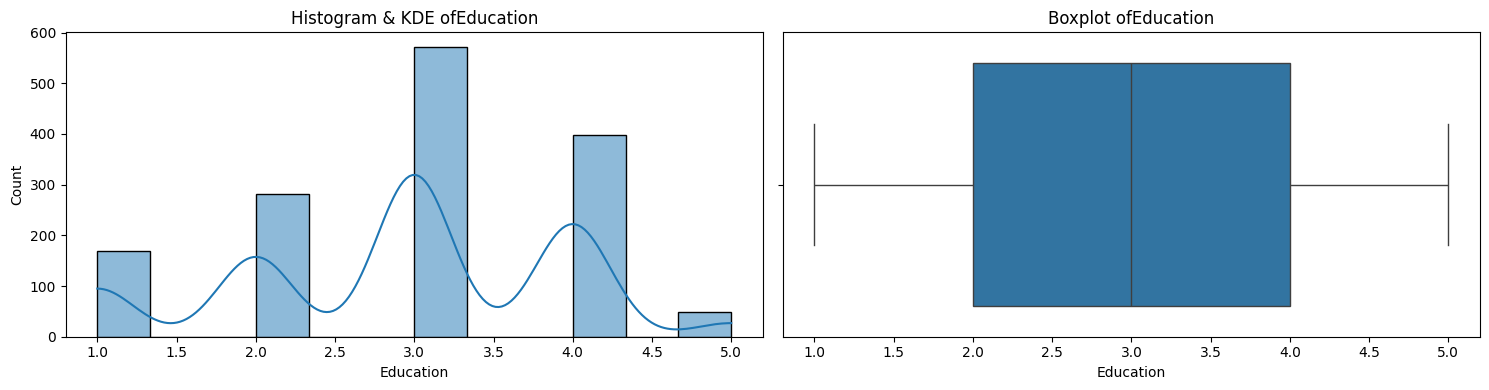


=====Numeric feature:NumCompaniesWorked =====
Mean: 2.69 Median: 2.0
Mean - Median Difference %: 25.74 %
Skewness: 1.03


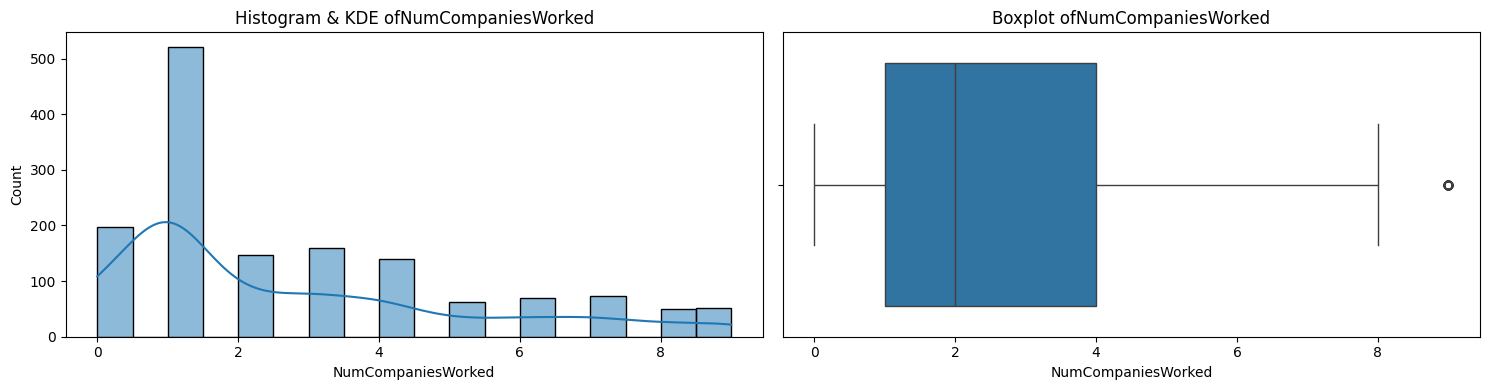


=====Numeric feature:RelationshipSatisfaction =====
Mean: 2.71 Median: 3.0
Mean - Median Difference %: 10.61 %
Skewness: -0.3


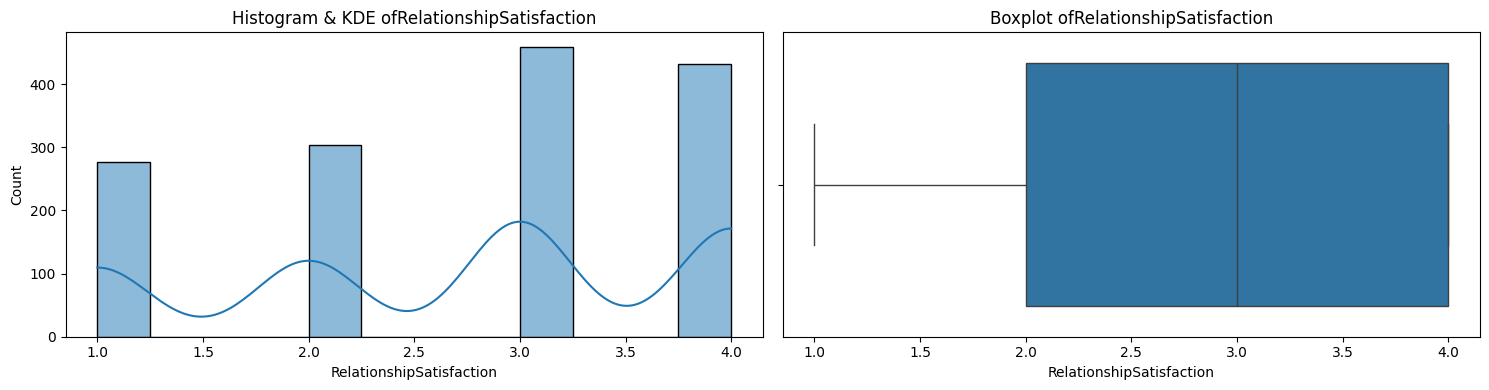


=====Numeric feature:YearsInCurrentRole =====
Mean: 4.23 Median: 3.0
Mean - Median Difference %: 29.07 %
Skewness: 0.92


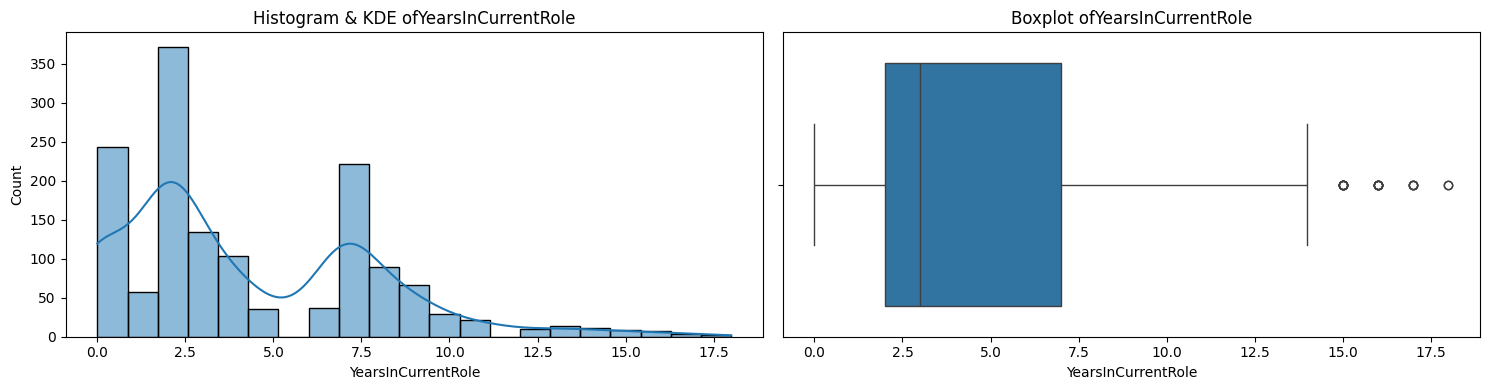


=====Numeric feature:YearsSinceLastPromotion =====
Mean: 2.19 Median: 1.0
Mean - Median Difference %: 54.29 %
Skewness: 1.98


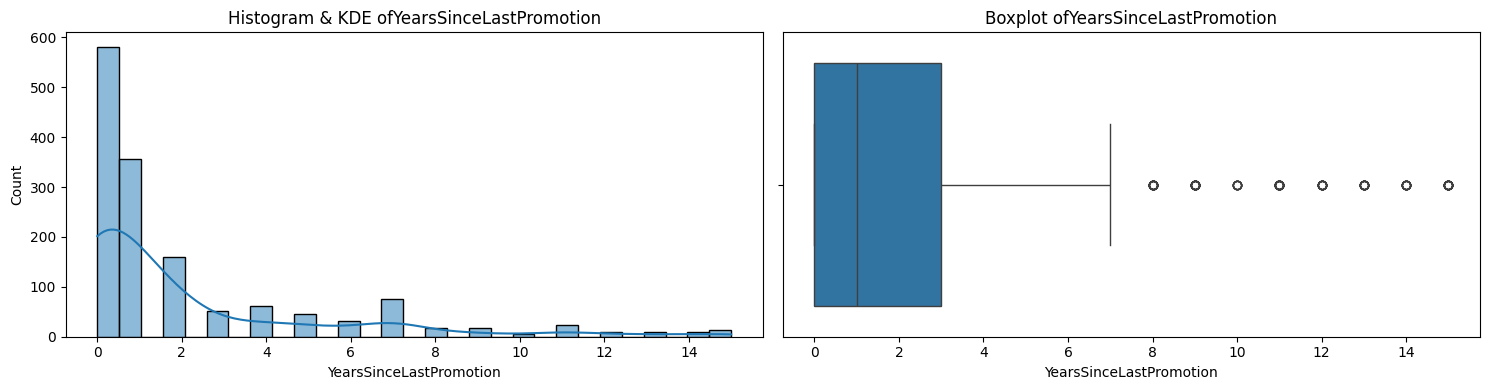


=====Numeric feature:YearsWithCurrManager =====
Mean: 4.12 Median: 3.0
Mean - Median Difference %: 27.24 %
Skewness: 0.83


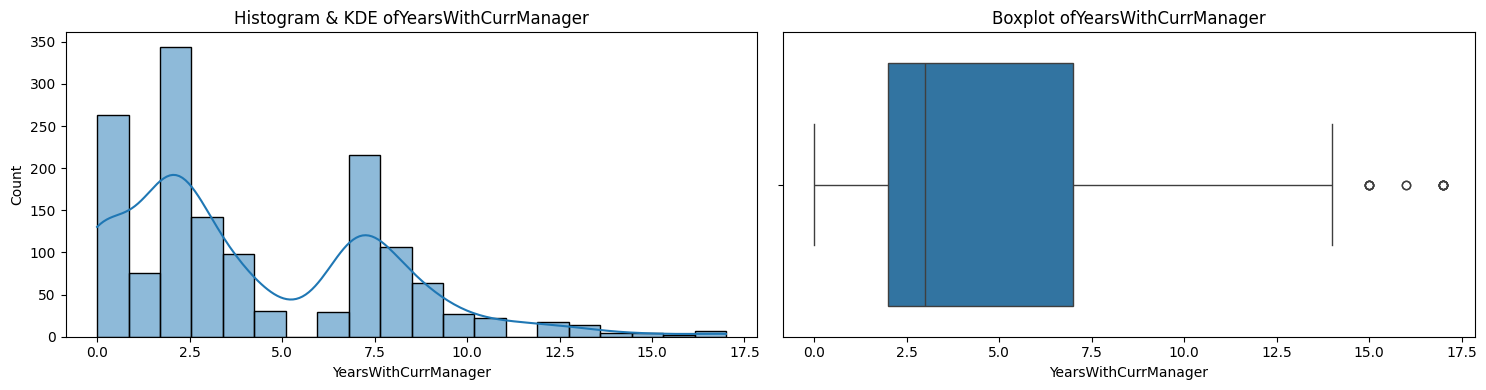

In [16]:
# univariate analyse of num_cols

num_cols = ['Age','DistanceFromHome','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome','PerformanceRating','WorkLifeBalance','TotalWorkingYears','YearsAtCompany',
            'Education','NumCompaniesWorked','RelationshipSatisfaction','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
for col in num_cols:
    print(f"\n=====Numeric feature:{col} =====")

# mean, median,diff
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    dif_percent = abs(mean_val - median_val)/mean_val*100

    print ("Mean:", round(mean_val,2),
          "Median:", round(median_val,2))
    print("Mean - Median Difference %:",round(dif_percent,2),"%")

#skewness   
    skew_val = df_clean[col].skew()
    print("Skewness:", round(skew_val,2))

#subplots = histogram , boxplot
    fig,axes = plt.subplots(1,2,figsize=(15,4))

    sns.histplot(df_clean[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram & KDE of{col}")

#boxplot for outliers:
    sns.boxplot(x=df_clean[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of{col}")

    plt.tight_layout()
    plt.show()

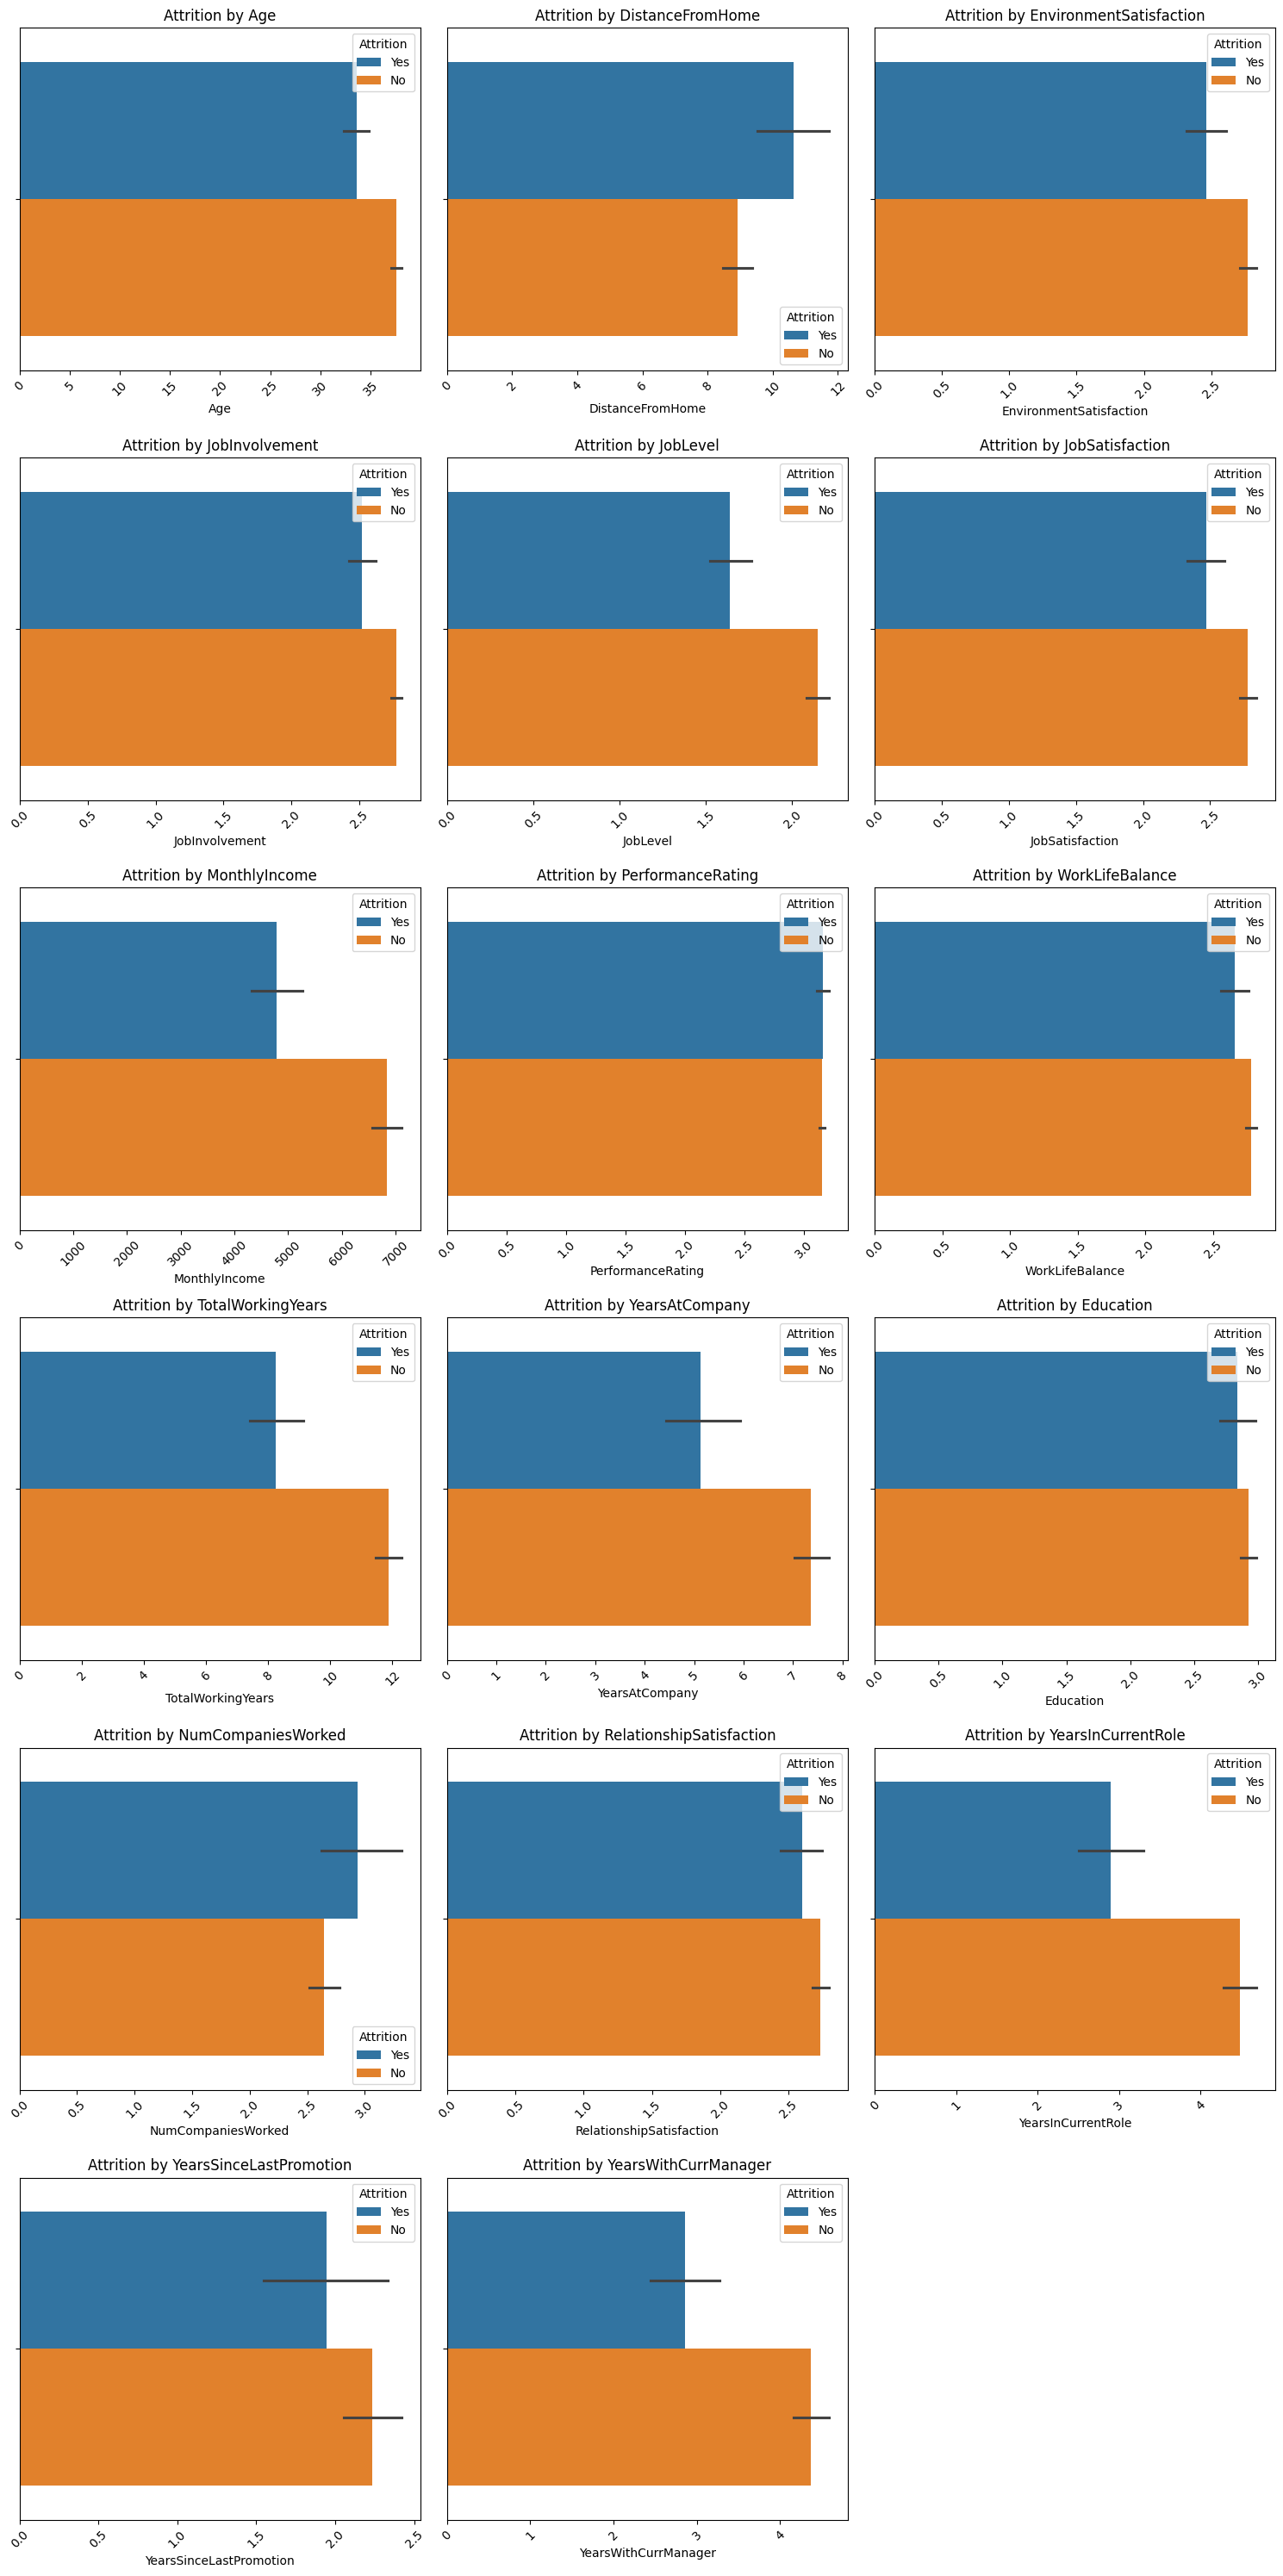

In [17]:
# bivariate anlyse of num_cols:
plt.figure(figsize=(15,30))
for i, col in enumerate(num_cols,1):
    plt.subplot(6,3,i)
    sns.barplot(data=df_clean,x= col, hue="Attrition")
    plt.title(f"Attrition by {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Lower Bound: -5291.0
Upper Bound: 16581.0
Number of outliers: 114


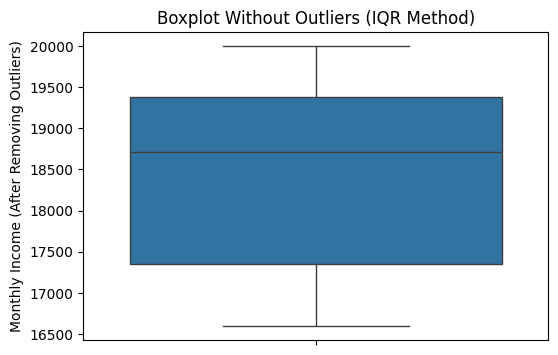

In [101]:
# TREATING OULIERS
#1

Q1 = df_clean['MonthlyIncome'].quantile(0.25)
Q3 = df_clean['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
outliers = df_clean[(df_clean['MonthlyIncome'] < lower_bound) | (df_clean['MonthlyIncome'] > upper_bound)]
print("Number of outliers:", len(outliers))
median = df_clean['MonthlyIncome'].median()

df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].apply(
    lambda x: median if (x < lower_bound or x > upper_bound) else x)

plt.figure(figsize=(6,4))
sns.boxplot(y=outliers['MonthlyIncome'])
plt.ylabel("Monthly Income (After Removing Outliers)")
plt.title("Boxplot Without Outliers (IQR Method)")
plt.show()

Lower Bound: -4.5
Upper Bound: 7.5
Number of outliers: 107


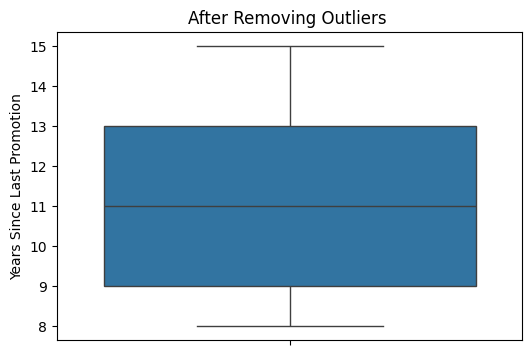

In [104]:
#2
Q1 = df_clean['YearsSinceLastPromotion'].quantile(0.25)
Q3 = df_clean['YearsSinceLastPromotion'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
outliers = df_clean[(df_clean['YearsSinceLastPromotion'] < lower_bound) | (df_clean['YearsSinceLastPromotion'] > upper_bound)]
print("Number of outliers:", len(outliers))

median = df_clean['YearsSinceLastPromotion'].median()

df_clean['YearsSinceLastPromotion'] = df_clean['YearsSinceLastPromotion'].apply(
    lambda x: median if (x < lower_bound or x > upper_bound) else x
)

plt.figure(figsize=(6,4))
sns.boxplot(y=outliers["YearsSinceLastPromotion"])
plt.title("After Removing Outliers ")
plt.ylabel("Years Since Last Promotion")
plt.show()

Lower Bound: -6.0
Upper Bound: 18.0
Number of outliers: 104


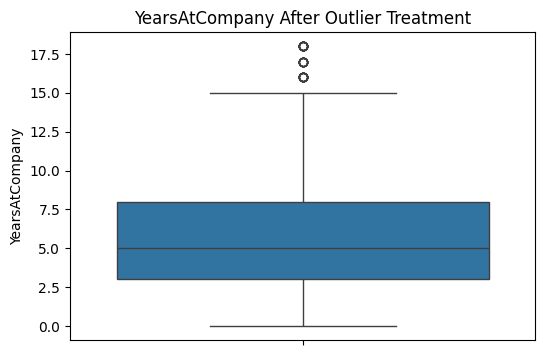

In [103]:
#3
Q1 = df_clean['YearsAtCompany'].quantile(0.25)
Q3 = df_clean['YearsAtCompany'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
outliers = df_clean[(df_clean['YearsAtCompany'] < lower_bound) | (df_clean['YearsAtCompany'] > upper_bound)]
print("Number of outliers:", len(outliers))
df_clean['YearsAtCompany'] = df_clean['YearsAtCompany'].apply(
    lambda x: median_val if (x < lower_bound or x > upper_bound) else x
)
plt.figure(figsize=(6,4))
sns.boxplot(y=df_clean['YearsAtCompany'])
plt.title("YearsAtCompany After Outlier Treatment")
plt.show()



Lower Bound: -5.5
Upper Bound: 14.5
Number of outliers: 21


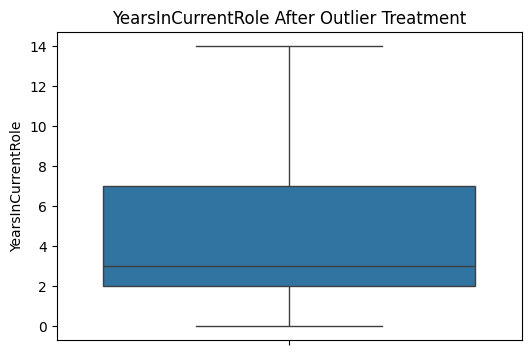

In [102]:
#4
Q1 = df_clean['YearsInCurrentRole'].quantile(0.25)
Q3 = df_clean['YearsInCurrentRole'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
outliers = df_clean[(df_clean['YearsInCurrentRole'] < lower_bound) | (df_clean['YearsInCurrentRole'] > upper_bound)]
print("Number of outliers:", len(outliers))
median_val = df_clean['YearsInCurrentRole'].median()

df_clean['YearsInCurrentRole'] = df_clean['YearsInCurrentRole'].apply(
    lambda x: median_val if (x < lower_bound or x > upper_bound) else x
)

plt.figure(figsize=(6,4))
sns.boxplot(y=df_clean['YearsInCurrentRole'])
plt.title("YearsInCurrentRole After Outlier Treatment")
plt.show()

In [105]:
# df_clean is your cleaned DataFrame
# Attrition is the target column (0/1)

y = df_clean["Attrition"]          # target vector
X = df_clean.drop(columns=["Attrition"])  # feature matrix

In [106]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    sampling_strategy="minority",  # make minority equal to majority
    random_state=42
)
X_train_sm, y_train_sm = smote.fit_resample(X,y)
print("Original train class counts:")
print(y.value_counts())
print("\nAfter SMOTE train class counts:")
print(y_train_sm.value_counts())

Original train class counts:
Attrition
0    1233
1     237
Name: count, dtype: int64

After SMOTE train class counts:
Attrition
1    1233
0    1233
Name: count, dtype: int64


In [107]:
from sklearn.preprocessing import StandardScaler
numb_cols = ['MonthlyIncome','Age','DistanceFromHome','MonthlyRate','NumCompaniesWorked']

scaler = StandardScaler()
df_clean[numb_cols] = scaler.fit_transform(df_clean[numb_cols])

In [108]:
df_clean

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,JobLevel,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Education_Technical Degree,Role_Healthcare Representative,Role_Human Resources,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative
0,0.446350,1,-1.010909,2,2,1,2,4,0,0.167809,...,False,False,False,False,False,False,False,False,True,False
1,1.322365,0,-0.147150,1,3,0,2,2,1,-0.102624,...,False,False,False,False,False,False,False,True,False,False
2,0.008343,1,-0.887515,2,4,0,1,3,0,-1.055253,...,False,False,False,True,False,False,False,False,False,False
3,-0.429664,0,-0.764121,4,4,1,1,3,1,-0.798607,...,False,False,False,False,False,False,False,True,False,False
4,-1.086676,0,-0.887515,1,1,0,1,2,1,-0.623436,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,0,1.703764,2,3,0,2,4,1,-0.904524,...,False,False,False,True,False,False,False,False,False,False
1466,0.227347,0,-0.393938,1,4,0,3,1,1,1.420641,...,False,True,False,False,False,False,False,False,False,False
1467,-1.086676,0,-0.640727,3,2,0,2,2,1,0.214501,...,False,False,False,False,False,True,False,False,False,False
1468,1.322365,0,-0.887515,3,4,0,2,2,1,-0.021150,...,False,False,False,False,False,False,False,False,True,False


In [109]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_train_sm,y_train_sm,test_size=0.2,random_state=42)


In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score ,roc_auc_score

rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [111]:
y_pred_rf=rf.predict(X_test)

y_proba_rf = rf.predict_proba(X_test)[:, 1]


In [112]:


print("Accuracy (RF):", accuracy_score(y_test, y_pred_rf))
print("\nClassification report (RF):\n", classification_report(y_test, y_pred_rf))
print("\nConfusion matrix (RF):\n", confusion_matrix(y_test, y_pred_rf))
print("\nROC-AUC (RF):", roc_auc_score(y_test, y_proba_rf))

Accuracy (RF): 0.9149797570850202

Classification report (RF):
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       250
           1       0.94      0.88      0.91       244

    accuracy                           0.91       494
   macro avg       0.92      0.91      0.91       494
weighted avg       0.92      0.91      0.91       494


Confusion matrix (RF):
 [[237  13]
 [ 29 215]]

ROC-AUC (RF): 0.9717868852459016


In [113]:
#to save the model in pickle format
import pickle

In [114]:
# X is your FINAL training dataframe 
feature_columns = X.columns.tolist()

artifacts = {
    "model": rf,
    "feature_columns": feature_columns
}

with open("attrition_model.pkl", "wb") as f:
    pickle.dump(artifacts, f)